# 1987 Black Monday — Market Break Detection

Identifies the precise timestamp of the October 19, 1987 market break using **multivariate PELT changepoint detection** on market microstructure features.

**Key Insight:** The "market break" is NOT just the highest volatility point, but a **structural regime shift** where the price formation mechanism fundamentally changed.

**Detection Method:** Three dysfunction features are computed on rolling windows (15m, 30m):
1. **Staleness** — Fraction of prices not updating (NaN + zero returns)
2. **Autocorrelation** — Lag-1 serial dependence (bid-ask bounce patterns)
3. **Jump-Share** — Proportion of discontinuous large moves (>2 sigma)

| Output | Description |
|---|---|
| `outputs/market_break_changepoint.png` | Visualisation with price + features |
| `outputs/break_summary.txt` | Detailed analysis report |

**Data:** `data/1987_crash_market_data.csv` (S&P 500 Futures, Oct 16–21, 1-minute)


## 1. Imports & Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')

# Try to import ruptures; install if needed
try:
    import ruptures
except ImportError:
    print("[Warning] 'ruptures' library not found. Installing...")
    os.system("pip install ruptures")
    import ruptures

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Configuration

In [2]:
DATA_PATH = "data/1987_crash_market_data.csv"
TIMESTAMP_COL = "Timestamp"
PRICE_COL = "SP500_Futures"
TIMESTAMP_FORMAT = "%m/%d/%Y %H:%M"

# NYSE trading hours (9:30 AM - 4:00 PM)
TRADING_HOURS = {
    "start": 9.5,   # 9:30 AM
    "end": 16.0     # 4:00 PM
}

# Rolling window sizes (in minutes)
WINDOW_SIZES = [15, 30]

# PELT penalty: pen=5 gives early detection with low false positives
PELT_PENALTY = 5

OUTPUT_DIR = "outputs"

print(f"Config loaded. Data path: {DATA_PATH}")


Config loaded. Data path: data/1987_crash_market_data.csv


## 3. Helper Functions

### 3.1 Configuration Validator

In [3]:
def validate_config(df, price_col, window_sizes, trading_hours):
    errors = []
    if price_col not in df.columns:
        errors.append(f"Price column '{price_col}' not found. Available: {list(df.columns)}")
    if "Timestamp" not in df.columns:
        errors.append(f"Timestamp column not found.")
    if "is_halted" not in df.columns:
        errors.append("is_halted column missing (should be created during data cleaning)")
    min_required = max(window_sizes) + 1
    if len(df) < min_required:
        errors.append(f"Insufficient data: {len(df)} rows < {min_required} minimum")
    if trading_hours["start"] >= trading_hours["end"]:
        errors.append(f"Invalid trading hours.")
    if errors:
        raise ValueError("Validation failed:\n" + "\n".join([f"  - {e}" for e in errors]))
    return True


### 3.2 Data Loading

In [4]:
def load_data(path, ts_col=TIMESTAMP_COL, ts_fmt=TIMESTAMP_FORMAT):
    """Load CSV and parse timestamps."""
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        sys.exit(f"ERROR: Data file not found at '{path}'.")
    if ts_col not in df.columns:
        sys.exit(f"ERROR: Timestamp column '{ts_col}' not found. Available columns: {list(df.columns)}")
    df["Timestamp"] = pd.to_datetime(df[ts_col], format=ts_fmt)
    df = df.sort_values("Timestamp").reset_index(drop=True)
    return df


### 3.3 Data Cleaning

> **Critical:** Do NOT forward-fill halted periods — this corrupts rolling statistics.

In [5]:
def clean_data(df, price_col=PRICE_COL):
    numeric_cols = ["DOW_Futures", "SP500_Futures", "MMI_Futures",
                    "Treasury", "Nikkei_Futures", "Gold_Futures", "Oil_Futures"]

    df["is_halted"] = False
    if price_col in df.columns:
        halted_mask = df[price_col].astype(str).str.contains("Halted", case=False, na=False)
        df.loc[halted_mask, "is_halted"] = True

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    available_numeric = [c for c in numeric_cols if c in df.columns]
    if available_numeric:
        halted_counts = df[available_numeric].isna().sum()
        if halted_counts.any():
            print("\n[Cleaning] NaN values found (e.g., 'Halted' strings):")
            print(halted_counts[halted_counts > 0].to_string())

    # ** DO NOT FORWARD-FILL **
    return df


### 3.4 Gap-Aware Returns

In [6]:
def compute_gap_aware_returns(df, price_col=PRICE_COL,
                               trading_start=None, trading_end=None):
    """
    Compute minute-to-minute log returns respecting halts, session boundaries,
    and trading hours only.
    """
    if trading_start is None:
        trading_start = TRADING_HOURS["start"]
    if trading_end is None:
        trading_end = TRADING_HOURS["end"]

    df["date"] = df["Timestamp"].dt.date
    df["hour"] = df["Timestamp"].dt.hour
    df["minute"] = df["Timestamp"].dt.minute
    df["hour_min"] = df["hour"] + df["minute"] / 60.0
    df["log_return"] = np.nan

    for date_val in df["date"].unique():
        date_mask = df["date"] == date_val
        date_df = df[date_mask].copy()
        date_indices = df[date_mask].index

        trading_hour_mask = (date_df["hour_min"] >= trading_start) & (date_df["hour_min"] < trading_end)
        trading_hour_indices = date_indices[trading_hour_mask]
        trading_mask = ~df.loc[trading_hour_indices, "is_halted"].values
        trading_indices = trading_hour_indices[trading_mask]

        if len(trading_indices) > 1:
            for i in range(1, len(trading_indices)):
                curr_idx = trading_indices[i]
                prev_idx = trading_indices[i - 1]
                curr_price = df.loc[curr_idx, price_col]
                prev_price = df.loc[prev_idx, price_col]
                if pd.notna(curr_price) and pd.notna(prev_price) and prev_price != 0:
                    df.loc[curr_idx, "log_return"] = np.log(curr_price / prev_price)

    return df


### 3.5 Dysfunction Feature Engineering

Rolling windows reset at day boundaries — no overnight contamination.

In [7]:
def compute_dysfunction_features(df, window_15m=15, window_30m=30):
    feature_cols = []

    for window in [window_15m, window_30m]:
        prefix = f"w{window}"
        df[f"{prefix}_staleness"] = np.nan
        df[f"{prefix}_autocorr"] = np.nan
        df[f"{prefix}_jump_share"] = np.nan
        feature_cols.extend([f"{prefix}_staleness", f"{prefix}_autocorr", f"{prefix}_jump_share"])

        for date_val in sorted(df["date"].unique()):
            date_mask = df["date"] == date_val
            date_indices = df[date_mask].index
            if len(date_indices) < window:
                continue
            date_returns = df.loc[date_indices, "log_return"].values

            def rolling_staleness_day(returns, w):
                result = np.full(len(returns), np.nan)
                for i in range(w - 1, len(returns)):
                    window_vals = returns[i - w + 1:i + 1]
                    nan_count = np.isnan(window_vals).sum()
                    zero_count = np.sum(np.abs(np.nan_to_num(window_vals)) < 1e-10)
                    result[i] = (nan_count + zero_count) / len(window_vals)
                return result

            def rolling_autocorr_day(returns, w):
                result = np.full(len(returns), np.nan)
                for i in range(w - 1, len(returns)):
                    window_vals = returns[i - w + 1:i + 1]
                    clean = window_vals[~np.isnan(window_vals)]
                    if len(clean) >= 2 and np.std(clean) > 1e-10:
                        result[i] = pd.Series(clean).autocorr(lag=1)
                return result

            def rolling_jump_share_day(returns, w):
                result = np.full(len(returns), np.nan)
                for i in range(w - 1, len(returns)):
                    window_vals = returns[i - w + 1:i + 1]
                    clean = window_vals[~np.isnan(window_vals)]
                    if len(clean) >= 2 and np.std(clean) > 1e-10:
                        std_val = np.std(clean)
                        large_moves = np.sum(np.abs(clean) > 2 * std_val)
                        result[i] = large_moves / len(clean)
                return result

            df.loc[date_indices, f"{prefix}_staleness"] = rolling_staleness_day(date_returns, window)
            df.loc[date_indices, f"{prefix}_autocorr"] = rolling_autocorr_day(date_returns, window)
            df.loc[date_indices, f"{prefix}_jump_share"] = rolling_jump_share_day(date_returns, window)

    return df, feature_cols


### 3.6 PELT Changepoint Detection

In [8]:
def detect_changepoint_pelt(df, window=30):
    """
    Multivariate PELT on standardised [staleness, autocorr, jump_share].
    Returns (break_timestamp, break_index, break_price) or (None, None, None).
    """
    df["date_price_change"] = df.groupby("date")[PRICE_COL].transform(
        lambda x: (x.iloc[-1] / x.iloc[0] - 1) if len(x) > 1 else 0
    )
    crisis_date = df.loc[df["date_price_change"].idxmin(), "date"]

    df_crisis = df[(df["date"] == crisis_date) &
                   (df["hour_min"] >= TRADING_HOURS["start"]) &
                   (df["hour_min"] < TRADING_HOURS["end"])].copy()

    if len(df_crisis) == 0:
        print(f"[Warning] No trading data for crisis date {crisis_date}.")
        return None, None, None

    prefix = f"w{window}"
    active_features = [f"{prefix}_staleness", f"{prefix}_autocorr", f"{prefix}_jump_share"]
    feature_data = df_crisis[active_features].copy()
    valid_mask = feature_data.notna().all(axis=1)
    valid_idx = valid_mask[valid_mask].index

    if len(valid_idx) < 3:
        print(f"[Warning] Insufficient valid feature data for window {window}.")
        return None, None, None

    df_valid = df.loc[valid_idx].copy()
    X = feature_data.loc[valid_idx].values

    X_std = np.zeros_like(X)
    for col in range(X.shape[1]):
        col_mean = np.nanmean(X[:, col])
        col_std = np.nanstd(X[:, col])
        X_std[:, col] = (X[:, col] - col_mean) / col_std if col_std > 1e-10 else 0

    algo = ruptures.Pelt(model="rbf", min_size=1, jump=1).fit(X_std)
    breakpoints = algo.predict(pen=PELT_PENALTY)

    if len(breakpoints) > 0:
        break_point_idx = breakpoints[0]
        break_idx = df_valid.index[break_point_idx] if break_point_idx < len(df_valid) else df_valid.index[-1]
        break_ts = df.loc[break_idx, "Timestamp"]
        break_price = df.loc[break_idx, PRICE_COL]
        time_fmt = break_ts.strftime('%H:%M') if hasattr(break_ts, 'strftime') else str(break_ts)
        print(f"[Debug] PELT (window={window}) detected breakpoint at {time_fmt} on {crisis_date}")
        return break_ts, break_idx, break_price

    return None, None, None


### 3.7 Sensitivity Analysis & Break Selection

In [9]:
def perform_sensitivity_analysis(df, window_sizes=None):
    if window_sizes is None:
        window_sizes = WINDOW_SIZES
    results = {}
    for window in window_sizes:
        ts, idx, price = detect_changepoint_pelt(df, window=window)
        results[window] = {"timestamp": ts, "index": idx, "price": price}
    return results


def select_best_break(sensitivity_results):
    """
    Prefer 30m window (more stable). Fall back to 15m if needed.
    """
    ts_15m = sensitivity_results[15]["timestamp"]
    ts_30m = sensitivity_results[30]["timestamp"]
    if ts_30m is not None:
        return ts_30m, "30-min window (multivariate PELT changepoint, robust)"
    elif ts_15m is not None:
        return ts_15m, "15-min window (multivariate PELT changepoint)"
    return None, "No changepoint detected"


### 3.8 Output Summary Writer

In [10]:
def create_output_summary(df, selected_ts, sensitivity_results, justification):
    """Write analysis summary to outputs/break_summary.txt."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    summary_path = os.path.join(OUTPUT_DIR, "break_summary.txt")
    dataset_name = os.path.basename(DATA_PATH).replace("_data.csv", "").replace("_", " ").title()

    with open(summary_path, "w") as f:
        f.write(f"{dataset_name.upper()} -- MARKET BREAK DETECTION ANALYSIS\n")
        f.write("=" * 80 + "\n\n")
        f.write("EXECUTIVE SUMMARY\n" + "-" * 80 + "\n")
        f.write(f"Selected Market Break: {selected_ts.strftime('%B %d, %Y at %H:%M')}\n")
        f.write(f"Detection Method: {justification}\n")
        f.write(f"Definition: Structural regime shift in microstructure (via PELT changepoint)\n\n")

        f.write("METHODOLOGY\n" + "-" * 80 + "\n")
        f.write("1. FEATURE ENGINEERING:\n")
        f.write("   - Staleness, Serial Dependence (autocorr), Jump-Share\n\n")
        f.write("2. GAP-AWARE RETURNS: halted periods skipped, session boundaries respected\n\n")
        f.write("3. CHANGEPOINT DETECTION: PELT on standardised multivariate feature array\n\n")

        f.write("SENSITIVITY ANALYSIS\n" + "-" * 80 + "\n")
        for window in sorted(sensitivity_results.keys()):
            result = sensitivity_results[window]
            if result["timestamp"] is not None:
                ts = result["timestamp"]
                marker = " [SELECTED]" if ts == selected_ts else ""
                f.write(f"  {window}-min window:  {ts.strftime('%b %d, %H:%M')}{marker}\n")
            else:
                f.write(f"  {window}-min window:  (no breakpoint detected)\n")
        f.write("\n")

        f.write("DATA CONSTRAINTS & LIMITATIONS\n" + "-" * 80 + "\n")
        f.write("* Source: minute-by-minute S&P 500 Futures, Oct 16-21 1987\n")
        f.write("* Halted periods: 60 mins Oct 19, 90 mins Oct 20 (not forward-filled)\n")
        f.write("* Cannot directly measure cash basis, bid-ask spreads, or volume\n")
        f.write("\n" + "=" * 80 + "\n")

    print(f"[Output] Analysis summary saved -> {summary_path}")


### 3.9 Visualisation

In [11]:
def plot_changepoint_visualization(df, selected_ts, window=30):
    """
    Stacked subplot: SP500 price (top) + dysfunction features (bottom).
    Trading hours only, overnight gaps compressed.
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    plot_df = df.copy()
    plot_df["hour_min"] = plot_df["Timestamp"].dt.hour + plot_df["Timestamp"].dt.minute / 60.0
    plot_df["day_of_week"] = plot_df["Timestamp"].dt.dayofweek

    trading_mask = (plot_df["hour_min"] >= 9.5) & (plot_df["hour_min"] < 16.0) & (plot_df["day_of_week"] < 5)
    plot_df = plot_df[trading_mask].copy().sort_values("Timestamp").reset_index(drop=True)

    if len(plot_df) == 0:
        print("[Warning] No trading hours data found.")
        return

    plot_df["plot_timestamp"] = plot_df["Timestamp"]
    dates_list = sorted(plot_df["date"].unique())
    cumulative_offset = pd.Timedelta(0)

    for i, d in enumerate(dates_list):
        mask = plot_df["date"] == d
        if i > 0:
            prev_day_end = plot_df[plot_df["date"] == dates_list[i - 1]]["Timestamp"].max()
            curr_day_start = plot_df[plot_df["date"] == d]["Timestamp"].min()
            cumulative_offset += curr_day_start - prev_day_end
        plot_df.loc[mask, "plot_timestamp"] = plot_df.loc[mask, "Timestamp"] - cumulative_offset

    prefix = f"w{window}"
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={'height_ratios': [1, 1]})
    fig.subplots_adjust(top=0.92, bottom=0.12, hspace=0.35)

    # ── TOP: Price ──
    ax1.set_ylabel(f"{PRICE_COL} Price", fontsize=12, fontweight="bold", color="steelblue")
    ax1.plot(plot_df["plot_timestamp"], plot_df[PRICE_COL], color="steelblue", linewidth=2.0, label=PRICE_COL, zorder=3)
    ax1.tick_params(axis="y", labelcolor="steelblue")

    if selected_ts in df["Timestamp"].values:
        break_row = plot_df[plot_df["Timestamp"] == selected_ts]
        if len(break_row) > 0:
            break_price = break_row.iloc[0][PRICE_COL]
            break_plot_ts = break_row.iloc[0]["plot_timestamp"]
            ax1.axvline(x=break_plot_ts, color="red", linestyle="--", linewidth=3,
                       label=f"PELT Breakpoint: {selected_ts.strftime('%b %d %H:%M')}", zorder=4)
            ax1.scatter([break_plot_ts], [break_price], color="red", s=300, zorder=5,
                       marker="X", edgecolors="darkred", linewidth=2)

    day_colors = ["lightblue", "lightyellow"]
    for day_idx, date_val in enumerate(dates_list):
        day_data = plot_df[plot_df["date"] == date_val]
        if len(day_data) > 0:
            ax1.axvspan(day_data["plot_timestamp"].min(), day_data["plot_timestamp"].max(),
                        alpha=0.06, color=day_colors[day_idx % 2], zorder=0)

    crash_date = selected_ts.date()
    crash_data = plot_df[plot_df["date"] == crash_date]
    if len(crash_data) > 0:
        ax1.axvspan(crash_data["plot_timestamp"].min(), crash_data["plot_timestamp"].max(),
                    alpha=0.12, color="red", zorder=1, label="Crisis Day (Oct 19)")

    halted_data = df[df["is_halted"] == True]
    if len(halted_data) > 0:
        halt_groups = halted_data.groupby("date")["Timestamp"].agg(["min", "max"])
        halt_label_added = False
        for halt_date, (halt_start_ts, halt_end_ts) in halt_groups.iterrows():
            halt_range = plot_df[(plot_df["Timestamp"] >= halt_start_ts) & (plot_df["Timestamp"] <= halt_end_ts)]
            if len(halt_range) > 0:
                label = "Trading Halt" if not halt_label_added else None
                ax1.axvspan(halt_range["plot_timestamp"].min(), halt_range["plot_timestamp"].max(),
                            alpha=0.25, color="gold", zorder=2, label=label)
                halt_label_added = True

    ax1.legend(fontsize=10, loc="upper right", framealpha=0.95)
    ax1.grid(True, alpha=0.2, linestyle=":")
    ax1.set_title("1987 Black Monday: Market Break Detection via PELT Changepoint\n"
                  "Trading hours only (9:30am–4:00pm), Oct 16–21, 1987. Overnight gaps compressed.",
                  fontsize=13, fontweight="bold", pad=15)

    # ── BOTTOM: Features ──
    ax2.set_xlabel("Trading Date", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Feature Value", fontsize=12, fontweight="bold")
    ax2.plot(plot_df["plot_timestamp"], plot_df[f"{prefix}_staleness"], color="darkgreen",
             linewidth=2.0, label="Staleness (NaN + zero-return fraction)", alpha=0.85)
    ax2.plot(plot_df["plot_timestamp"], plot_df[f"{prefix}_autocorr"], color="orange",
             linewidth=2.0, label="Autocorrelation (AR lag-1)", alpha=0.85, linestyle="-.")
    ax2.plot(plot_df["plot_timestamp"], plot_df[f"{prefix}_jump_share"], color="crimson",
             linewidth=2.0, label="Jump-Share (discontinuity fraction)", alpha=0.85, linestyle=":")

    if selected_ts in df["Timestamp"].values:
        break_row = plot_df[plot_df["Timestamp"] == selected_ts]
        if len(break_row) > 0:
            ax2.axvline(x=break_row.iloc[0]["plot_timestamp"], color="red", linestyle="--", linewidth=2.5, alpha=0.7)

    crisis_data2 = plot_df[plot_df["date"] == crash_date]
    if len(crisis_data2) > 0:
        ax2.axvspan(crisis_data2["plot_timestamp"].min(), crisis_data2["plot_timestamp"].max(),
                    alpha=0.08, color="red", label="Crisis Day (Oct 19)")

    if len(halted_data) > 0:
        halt_label_added = False
        for halt_date, (halt_start_ts, halt_end_ts) in halt_groups.iterrows():
            halt_range = plot_df[(plot_df["Timestamp"] >= halt_start_ts) & (plot_df["Timestamp"] <= halt_end_ts)]
            if len(halt_range) > 0:
                label = "Trading Halt" if not halt_label_added else None
                ax2.axvspan(halt_range["plot_timestamp"].min(), halt_range["plot_timestamp"].max(),
                            alpha=0.15, color="gold", label=label)
                halt_label_added = True

    ax2.axhline(y=0, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    ax2.legend(fontsize=10, loc="upper left", framealpha=0.95)
    ax2.grid(True, alpha=0.2, linestyle=":")

    date_ticks, date_labels = [], []
    for d in dates_list:
        day_data = plot_df[plot_df["date"] == d]
        if len(day_data) > 0:
            date_ticks.append(day_data["plot_timestamp"].min())
            date_labels.append(pd.Timestamp(d).strftime("%b %d"))

    for ax in [ax1, ax2]:
        ax.set_xticks(date_ticks)
        ax.set_xticklabels(date_labels, rotation=0, fontsize=10)

    path = os.path.join(OUTPUT_DIR, "market_break_changepoint.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Output] Changepoint visualization -> {path}")


## 4. Run the Full Pipeline

Run the cells below in order. Outputs are saved to `outputs/`.


In [12]:
# Step 1: Load data
print("\n" + "=" * 80)
print("  1987 BLACK MONDAY -- MARKET BREAK DETECTION (PELT CHANGEPOINT)")
print("=" * 80 + "\n")
print("[Loading] Data...")
df = load_data(DATA_PATH)
print(f"  Rows: {len(df):,} | Columns: {list(df.columns)}")
df.head()



  1987 BLACK MONDAY -- MARKET BREAK DETECTION (PELT CHANGEPOINT)

[Loading] Data...
  Rows: 7,921 | Columns: ['Timestamp', 'DOW_Futures', 'SP500_Futures', 'MMI_Futures', 'Treasury', 'Nikkei_Futures', 'Gold_Futures', 'Oil_Futures']


,Timestamp,DOW_Futures,SP500_Futures,MMI_Futures,Treasury,Nikkei_Futures,Gold_Futures,Oil_Futures
0,1987-10-16 00:00:00,2355,298,450.0,95.0,26001.49,465.0,20.0
1,1987-10-16 00:01:00,2355,298,450.0,95.0,26001.08,465.0,20.0
2,1987-10-16 00:02:00,2355,298,450.0,95.0,26003.02,465.0,20.0
3,1987-10-16 00:03:00,2355,298,450.0,95.0,26007.59,465.0,20.0
4,1987-10-16 00:04:00,2355,298,450.0,95.0,26006.89,465.0,20.0


In [13]:
# Step 2: Clean
print("[Cleaning] Data (respecting halted-period constraints)...")
df = clean_data(df)


[Cleaning] Data (respecting halted-period constraints)...

[Cleaning] NaN values found (e.g., 'Halted' strings):
DOW_Futures      379
SP500_Futures    150


In [14]:
# Step 3: Validate
try:
    validate_config(df, PRICE_COL, WINDOW_SIZES, TRADING_HOURS)
    print("[Validation] Data and config compatible — proceeding...")
except ValueError as e:
    print(f"[ERROR] {e}")
    raise


[Validation] Data and config compatible — proceeding...


In [15]:
# Step 4: Gap-aware returns
print("[Computing] Gap-aware returns...")
df = compute_gap_aware_returns(df)
print(f"  Non-NaN log returns: {df['log_return'].notna().sum():,}")


[Computing] Gap-aware returns...
  Non-NaN log returns: 1,945


In [16]:
# Step 5: Dysfunction features
print("[Extracting] Dysfunction features (staleness, autocorr, jump-share)...")
df, feature_cols = compute_dysfunction_features(df, window_15m=15, window_30m=30)
print(f"  Features: {feature_cols}")


[Extracting] Dysfunction features (staleness, autocorr, jump-share)...
  Features: ['w15_staleness', 'w15_autocorr', 'w15_jump_share', 'w30_staleness', 'w30_autocorr', 'w30_jump_share']


In [17]:
# Step 6: Sensitivity analysis + break selection
print("[Running] Sensitivity analysis (PELT on 15m & 30m windows)...")
sensitivity_results = perform_sensitivity_analysis(df)
selected_ts, justification = select_best_break(sensitivity_results)

if selected_ts is None:
    raise RuntimeError("[ERROR] No changepoint detected. Check data and feature calculations.")

print(f"\n[Result] Market break detected: {selected_ts.strftime('%B %d, %Y at %H:%M')}")
print(f"[Justification] {justification}")


[Running] Sensitivity analysis (PELT on 15m & 30m windows)...
[Debug] PELT (window=15) detected breakpoint at 09:43 on 1987-10-19
[Debug] PELT (window=30) detected breakpoint at 09:42 on 1987-10-19

[Result] Market break detected: October 19, 1987 at 09:42
[Justification] 30-min window (multivariate PELT changepoint, robust)


In [18]:
# Step 7: Save text summary
print("\n[Creating] Output summary...")
create_output_summary(df, selected_ts, sensitivity_results, justification)



[Creating] Output summary...
[Output] Analysis summary saved -> outputs\break_summary.txt


[Plotting] Visualization (price + all dysfunction features)...


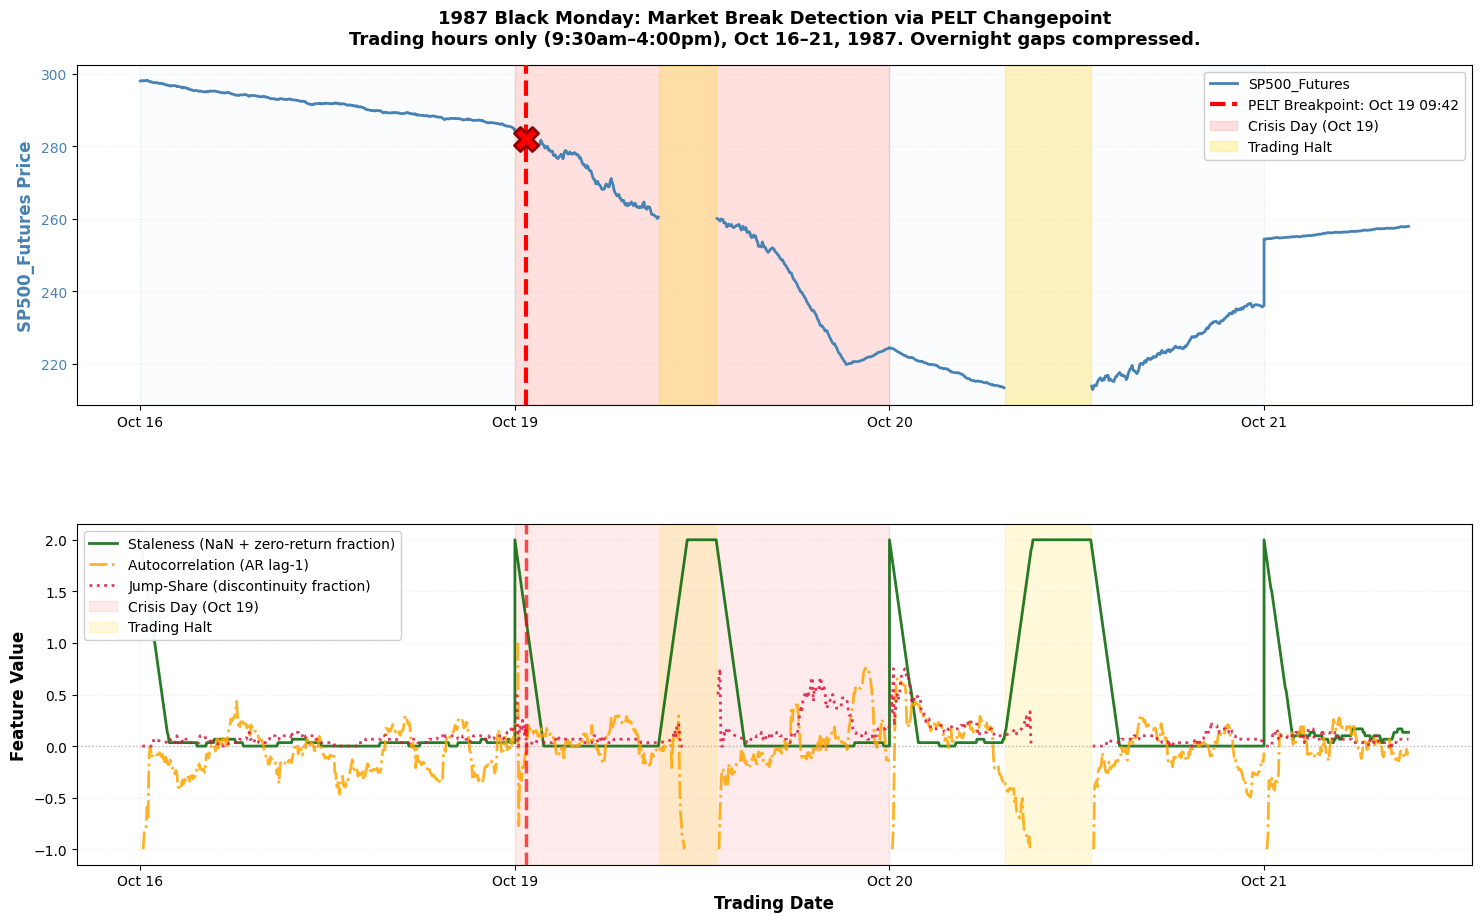

[Output] Changepoint visualization -> outputs\market_break_changepoint.png

[OK] Analysis complete. See outputs/ directory.



In [19]:
# Step 8: Plot
print("[Plotting] Visualization (price + all dysfunction features)...")
selected_window = 30 if sensitivity_results[30]["timestamp"] is not None else 15
plot_changepoint_visualization(df, selected_ts, window=selected_window)

print("\n" + "=" * 80)
print("[OK] Analysis complete. See outputs/ directory.")
print("=" * 80 + "\n")
